In [3]:
import pandas as pd
import numpy as np

In [4]:
prices = pd.DataFrame( {
    "BLUE": [8.7, 8.91, 8.71, 8.43, 8.73],
    "ORANGE": [10.66, 11.08, 10.71, 11.59, 12.11]
})

In [5]:
prices 

,BLUE,ORANGE
0,8.70,10.66
1,8.91,11.08
2,8.71,10.71
3,8.43,11.59
4,8.73,12.11


In [6]:
prices.iloc[1:]

,BLUE,ORANGE
1,8.91,11.08
2,8.71,10.71
3,8.43,11.59
4,8.73,12.11


In [7]:
prices.iloc[:-1]

,BLUE,ORANGE
0,8.70,10.66
1,8.91,11.08
2,8.71,10.71
3,8.43,11.59


In [8]:
prices.iloc[1:]/prices.iloc[:-1]

,BLUE,ORANGE
0,NaN,NaN
1,1.0,1.0
2,1.0,1.0
3,1.0,1.0
4,NaN,NaN


In [9]:
prices.iloc[1:].values/prices.iloc[:-1] - 1

,BLUE,ORANGE
0,0.024138,0.039400
1,-0.022447,-0.033394
2,-0.032147,0.082166
3,0.035587,0.044866


In [11]:
prices/prices.shift(1) - 1

,BLUE,ORANGE
0,NaN,NaN
1,0.024138,0.039400
2,-0.022447,-0.033394
3,-0.032147,0.082166
4,0.035587,0.044866


In [15]:
prices.pct_change()

,BLUE,ORANGE
0,NaN,NaN
1,0.024138,0.039400
2,-0.022447,-0.033394
3,-0.032147,0.082166
4,0.035587,0.044866


In [19]:
prices = pd.read_csv("data/sample_prices.csv")
returns = prices.pct_change()
returns.dropna()

,BLUE,ORANGE
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381
6,-0.011452,-0.049187
7,0.032676,0.117008
8,-0.012581,0.067353
9,0.029581,0.078249
10,0.006151,-0.168261


In [ ]:
returns.std()

BLUE      0.023977
ORANGE    0.079601
dtype: float64

In [ ]:
deviation = returns - returns.mean()
squared_deviation = deviation**2
variance = squared_deviation.mean()
volatility = np.sqrt(variance)
volatility 

BLUE      0.022957
ORANGE    0.076212
dtype: float64

In [35]:
number_of_obs = returns.shape[0]
variance1 = squared_deviation.sum() / (number_of_obs - 2)
volatility1 = np.sqrt(variance1)
volatility1

BLUE      0.023977
ORANGE    0.079601
dtype: float64

In [36]:
returns.std() * np.sqrt(12)

BLUE      0.083060
ORANGE    0.275747
dtype: float64

In [39]:
df = pd.read_csv("data/Portfolios_Formed_on_ME_monthly_EW.csv"
                 , header = 0, index_col = 0, parse_dates= True, na_values = -99)

/var/folders/d3/4j2xrjxn06v329lnxwrwmzs80000gn/T/ipykernel_62617/3286442993.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("data/Portfolios_Formed_on_ME_monthly_EW.csv"


In [40]:
df.head()

,<= 0,Lo 30,Med 40,Hi 30,Lo 20,Qnt 2,Qnt 3,Qnt 4,Hi 20,Lo 10,Dec 2,Dec 3,Dec 4,Dec 5,Dec 6,Dec 7,Dec 8,Dec 9,Hi 10
192607,-99.99,-0.43,1.52,2.68,-0.57,0.59,1.60,1.47,3.33,-1.45,0.29,-0.15,1.33,1.24,1.98,1.55,1.38,3.38,3.29
192608,-99.99,3.90,3.04,2.09,3.84,3.59,3.71,1.61,2.33,5.12,2.59,4.03,3.15,2.72,4.72,1.60,1.63,0.98,3.70
192609,-99.99,-1.08,-0.54,0.16,-0.48,-1.40,0.00,-0.50,-0.09,0.93,-1.87,-2.27,-0.53,0.07,-0.07,-1.64,0.64,-0.86,0.67
192610,-99.99,-3.32,-3.52,-3.06,-3.29,-4.10,-2.89,-3.36,-2.95,-4.84,-1.77,-3.36,-4.83,-2.98,-2.80,-3.45,-3.27,-3.47,-2.43
192611,-99.99,-0.46,3.82,3.09,-0.55,2.18,3.41,3.39,3.16,-0.78,-0.32,-0.29,4.65,3.24,3.57,3.82,2.95,3.61,2.70


In [42]:
columns = ['Lo 10', 'Hi 10']
df = df[columns]
df.head()

,Lo 10,Hi 10
192607,-1.45,3.29
192608,5.12,3.70
192609,0.93,0.67
192610,-4.84,-2.43
192611,-0.78,2.70


In [43]:
df = df / 100
df.head()

,Lo 10,Hi 10
192607,-0.0145,0.0329
192608,0.0512,0.0370
192609,0.0093,0.0067
192610,-0.0484,-0.0243
192611,-0.0078,0.0270


In [44]:
df.columns =  ["Small Cap", "Large Cap"]
df.head()

,Small Cap,Large Cap
192607,-0.0145,0.0329
192608,0.0512,0.0370
192609,0.0093,0.0067
192610,-0.0484,-0.0243
192611,-0.0078,0.0270


<Axes: >

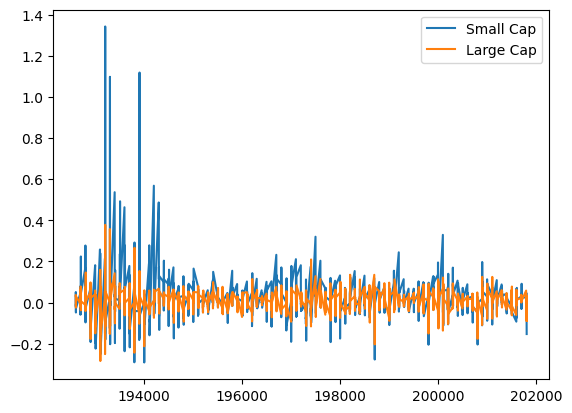

In [45]:
df.plot.line()

In [46]:
df.std()

Small Cap    0.106288
Large Cap    0.053900
dtype: float64

In [48]:
annualized_vol = df.std()*np.sqrt(12)
annualized_vol

Small Cap    0.368193
Large Cap    0.186716
dtype: float64

In [53]:
n_months = df.shape[0]
return_per_month = (1 + df).prod()**(1/n_months) - 1

In [55]:
annualized_returns = (return_per_month + 1)**12 - 1
annualized_returns

Small Cap    0.167463
Large Cap    0.092810
dtype: float64

In [56]:
annualized_returns/annualized_vol

Small Cap    0.454825
Large Cap    0.497063
dtype: float64

In [58]:
risk_free_rate = 0.03
excess_return = annualized_returns-risk_free_rate
sharp_ratio = excess_return/annualized_vol
sharp_ratio

Small Cap    0.373346
Large Cap    0.336392
dtype: float64